In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Naive Bayes Baseline for Intent Classification

This notebook trains a simple **TF-IDF + Multinomial Naive Bayes** baseline model for comparison with the fine-tuned DistilBERT model.

The goal is not optimization. The goal is to create a fast, simple baseline using the same intent dataset.

In [2]:
# If needed, run this first:
#!pip install pandas scikit-learn matplotlib joblib

In [3]:
import time
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Load Train / Validation / Test Split



In [4]:
# 1. Import the same BERT train / validation / test splits

EXPORT_DIR = "/content/drive/MyDrive/AIE_Project/intent_classification_datasets/"

TRAIN_PATH = f"{EXPORT_DIR}train_augmented_02.csv"
VALIDATION_PATH = f"{EXPORT_DIR}val_02.csv"
TEST_PATH = f"{EXPORT_DIR}test_02.csv"

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VALIDATION_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain label distribution:")
print(train_df["label"].value_counts())

print("\nValidation label distribution:")
print(val_df["label"].value_counts())

print("\nTest label distribution:")
print(test_df["label"].value_counts())

Train shape: (5400, 2)
Validation shape: (88, 2)
Test shape: (89, 2)

Train label distribution:
label
complaint                    600
general_question             600
logistics                    600
payment                      600
product_inquiry              600
refund                       600
self_harm_or_suicide_risk    600
technical_support            600
unknown                      600
Name: count, dtype: int64

Validation label distribution:
label
self_harm_or_suicide_risk    13
logistics                    11
general_question             10
payment                       9
product_inquiry               9
technical_support             9
unknown                       9
refund                        9
complaint                     9
Name: count, dtype: int64

Test label distribution:
label
self_harm_or_suicide_risk    14
general_question             11
logistics                    10
unknown                       9
refund                        9
payment                       9

##Train Naive Bayes Baseline

In [5]:
nb_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=1
    )),
    ("classifier", MultinomialNB())
])

nb_model.fit(train_df["text"], train_df["label"])

print("Naive Bayes baseline trained successfully.")

Naive Bayes baseline trained successfully.


## Evaluate on Validation Set

In [6]:
val_pred = nb_model.predict(val_df["text"])

print("Validation Accuracy:", round(accuracy_score(val_df["label"], val_pred), 4))
print("Validation Macro F1:", round(f1_score(val_df["label"], val_pred, average="macro"), 4))

print("\nValidation Classification Report:")
print(classification_report(val_df["label"], val_pred, digits=4))

Validation Accuracy: 0.7386
Validation Macro F1: 0.7247

Validation Classification Report:
                           precision    recall  f1-score   support

                complaint     0.8000    0.8889    0.8421         9
         general_question     0.6667    0.6000    0.6316        10
                logistics     0.7500    0.8182    0.7826        11
                  payment     0.6667    0.4444    0.5333         9
          product_inquiry     0.7778    0.7778    0.7778         9
                   refund     0.5000    0.7778    0.6087         9
self_harm_or_suicide_risk     0.8571    0.9231    0.8889        13
        technical_support     0.8000    0.8889    0.8421         9
                  unknown     1.0000    0.4444    0.6154         9

                 accuracy                         0.7386        88
                macro avg     0.7576    0.7293    0.7247        88
             weighted avg     0.7609    0.7386    0.7324        88



## Validation Set Confusion Matrix

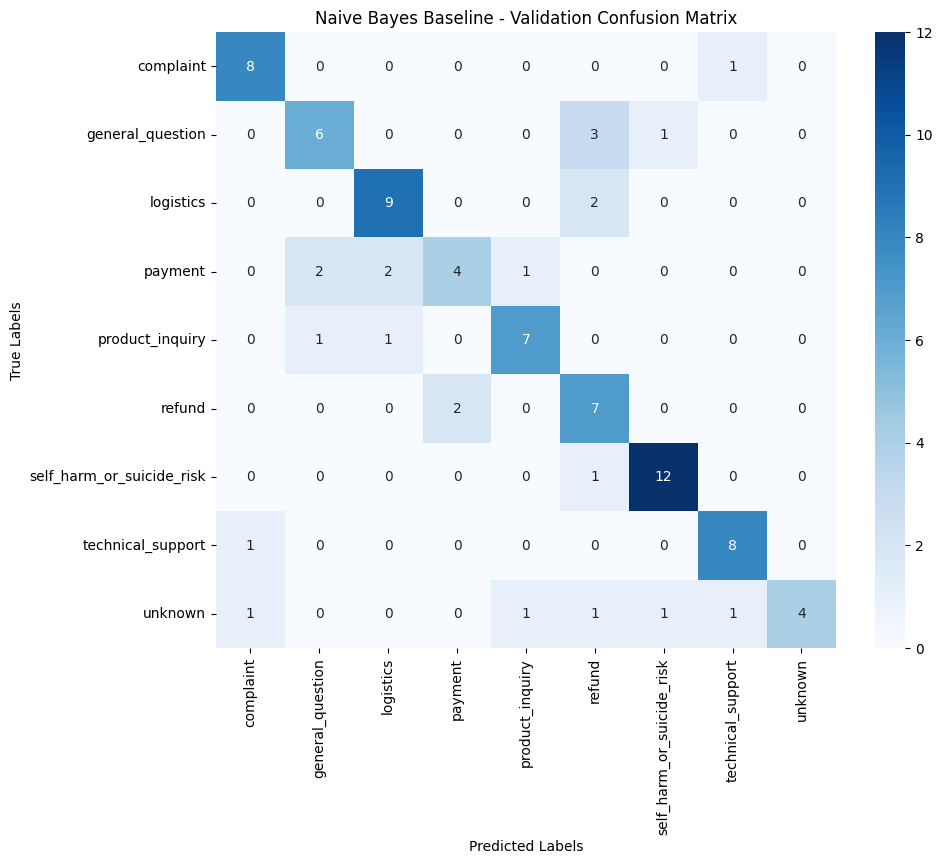

In [8]:
labels = sorted(train_df["label"].unique())

cm = confusion_matrix(val_df["label"], val_pred,labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Naive Bayes Baseline - Validation Confusion Matrix')
plt.show()

##Evaluate on Test Set

In [9]:
test_pred = nb_model.predict(test_df["text"])

print("Test Accuracy:", round(accuracy_score(test_df["label"], test_pred), 4))
print("Test Macro F1:", round(f1_score(test_df["label"], test_pred, average="macro"), 4))

print("\nTest Classification Report:")
print(classification_report(test_df["label"], test_pred, digits=4))

Test Accuracy: 0.6966
Test Macro F1: 0.6825

Test Classification Report:
                           precision    recall  f1-score   support

                complaint     0.8000    0.4444    0.5714         9
         general_question     0.6667    0.7273    0.6957        11
                logistics     0.6364    0.7000    0.6667        10
                  payment     0.6364    0.7778    0.7000         9
          product_inquiry     1.0000    0.5556    0.7143         9
                   refund     0.5294    1.0000    0.6923         9
self_harm_or_suicide_risk     0.7692    0.7143    0.7407        14
        technical_support     0.8182    1.0000    0.9000         9
                  unknown     0.7500    0.3333    0.4615         9

                 accuracy                         0.6966        89
                macro avg     0.7340    0.6947    0.6825        89
             weighted avg     0.7334    0.6966    0.6859        89



## Confusion Matrix

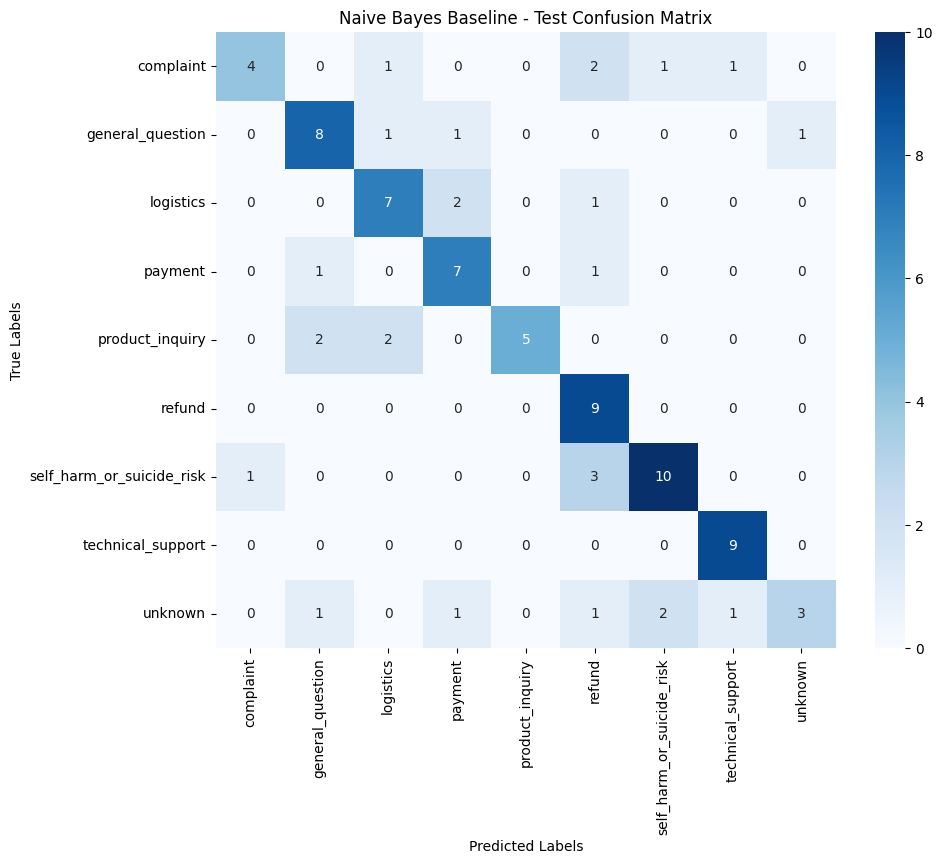

In [10]:
labels = sorted(train_df["label"].unique())

cm = confusion_matrix(test_df["label"], test_pred,labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Naive Bayes Baseline - Test Confusion Matrix')
plt.show()

##Save Baseline Model

In [11]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
model_path = f"naive_bayes_intent_baseline_{timestamp}.joblib"

joblib.dump(nb_model, model_path)

print("Saved model to:", model_path)

Saved model to: naive_bayes_intent_baseline_20260621_0821.joblib
